In [ ]:
# Importar librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datasets desde el repositorio de la sesión (del TPS)
# Usamos el separador ';' porque es el formato de tus archivos
facturas = pd.read_csv('facturas.txt', sep=';', names=['Hora', 'Nombre_Cliente', 'Afiliacion', 'Producto', 'Precio', 'Cantidad'])
productos = pd.read_csv('productos.txt', sep=';', names=['ID', 'Producto', 'Categoria', 'Precio_Unitario', 'Stock'])
clientes = pd.read_csv('clientes.txt', sep=';', names=['ID', 'Nombre', 'Cedula', 'Tipo'])

# Procesamiento inicial: Crear columna de ingreso total por transacción
facturas['Ingreso'] = facturas['Precio'] * facturas['Cantidad']
print("Datos cargados y procesados correctamente.")

Datos cargados y procesados correctamente.


In [ ]:
# Unir facturas con productos para obtener categorías
df = pd.merge(facturas, productos[['Producto', 'Categoria']], on='Producto', how='left')

# KPI 1: Conteo de visitas por cliente (Regla de negocio: 18 visitas = bono)
kpi1 = facturas.groupby('Nombre_Cliente')['Hora'].count().reset_index()
kpi1.columns = ['Cliente', 'Visitas']

# KPI 2: Consumo promedio por categoría (Regla de negocio: Estrategia de precios)
kpi2 = df.groupby('Categoria')['Ingreso'].mean().reset_index()
kpi2.columns = ['Categoria', 'Promedio_Consumo']

# KPI 3: Participación de ingresos por categoría
kpi3 = df.groupby('Categoria')['Ingreso'].sum().reset_index()
total = kpi3['Ingreso'].sum()
kpi3['Participacion'] = (kpi3['Ingreso'] / total) * 100
print("KPIs calculados con éxito.")

KPIs calculados con éxito.


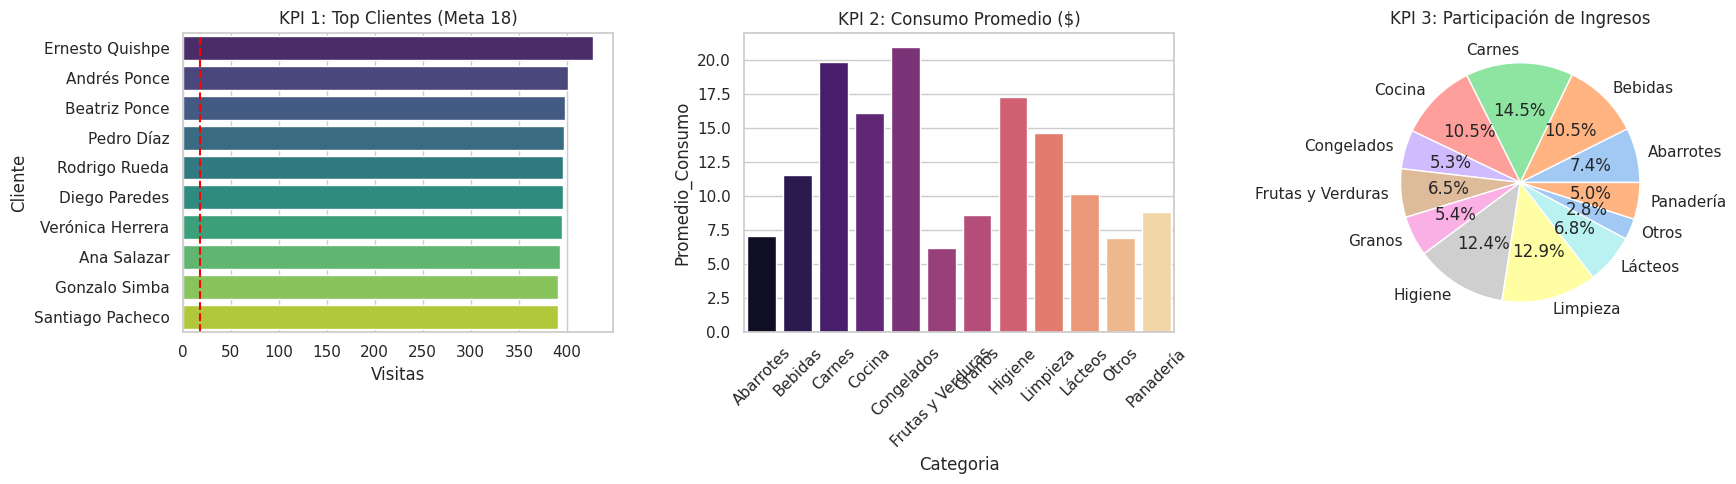

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Top 10 Clientes (Con línea de meta en 18)
top_10 = kpi1.sort_values(by='Visitas', ascending=False).head(10)
sns.barplot(data=top_10, x='Visitas', y='Cliente', ax=axes[0], palette='viridis', hue='Cliente', legend=False)
axes[0].set_title('KPI 1: Top Clientes (Meta 18)')
axes[0].axvline(18, color='red', linestyle='--', label='Meta')

# Gráfico 2: Promedio de Consumo
sns.barplot(data=kpi2, x='Categoria', y='Promedio_Consumo', ax=axes[1], palette='magma', hue='Categoria', legend=False)
axes[1].set_title('KPI 2: Consumo Promedio ($)')
axes[1].tick_params(axis='x', rotation=45)

# Gráfico 3: Participación
axes[2].pie(kpi3['Participacion'], labels=kpi3['Categoria'], autopct='%1.1f%%', colors=sns.color_palette("pastel"))
axes[2].set_title('KPI 3: Participación de Ingresos')

plt.tight_layout()
plt.show()